# Module 5 - Data Science Mini Project

## Customer Shopping Intelligence & Segmentation

### Codomax Data Scientist Internship

This project analyzes customer shopping behavior to identify purchasing patterns, customer segments, and potential business opportunities.

### Project Objective

The objective is to transform raw customer shopping data into meaningful insights through data cleaning, exploratory data analysis, feature engineering, customer segmentation, and data visualization.

### Key Business Questions

- Which product categories generate the most sales?
- Which products are purchased most frequently?
- Which age groups spend the most?
- How does purchasing behavior differ by gender?
- Which seasons show stronger purchasing activity?
- What payment methods are most popular?
- How does subscription status relate to spending?
- How are discounts associated with purchase behavior?
- Which customer groups appear to have higher purchasing value?

### Project Workflow

Data Understanding → Data Quality → Cleaning → Feature Engineering → Exploratory Analysis → Customer Segmentation → Visualization → Insights → Business Recommendations

In [59]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [60]:
# Load the primary dataset

df = pd.read_csv("shopping_trends_updated.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 3900
Columns: 18


## 1. Dataset Understanding

Before analyzing the data, we first examine its structure, variables, and basic statistics.

In [61]:
# Display the first five rows

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [62]:
# Display the last five rows

df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [63]:
# Display dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3900
Number of columns: 18


In [64]:
# Display column names

print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- Customer ID
- Age
- Gender
- Item Purchased
- Category
- Purchase Amount (USD)
- Location
- Size
- Color
- Season
- Review Rating
- Subscription Status
- Shipping Type
- Discount Applied
- Promo Code Used
- Previous Purchases
- Payment Method
- Frequency of Purchases


In [65]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [66]:
# Display descriptive statistics

df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## 2. Data Quality Check

We check the dataset for missing values, duplicate records, and possible data-quality issues before performing analysis.

In [67]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Total missing values: 0


In [68]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [69]:
# Check data types

df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [70]:
# Check unique values for important categorical columns

categorical_columns = [
    "Gender",
    "Category",
    "Season",
    "Subscription Status",
    "Payment Method",
    "Frequency of Purchases"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Gender:
['Male' 'Female']

Category:
['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Season:
['Winter' 'Spring' 'Summer' 'Fall']

Subscription Status:
['Yes' 'No']

Payment Method:
['Venmo' 'Cash' 'Credit Card' 'PayPal' 'Bank Transfer' 'Debit Card']

Frequency of Purchases:
['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']


## 3. Data Cleaning

The dataset is cleaned and verified before deeper analysis. Since the quality checks determine the required cleaning actions, we avoid making unnecessary changes to valid data.

In [71]:
# Remove duplicate rows if any

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before cleaning:", before)
print("Rows after removing duplicates:", after)
print("Rows removed:", before - after)

Rows before cleaning: 3900
Rows after removing duplicates: 3900
Rows removed: 0


In [72]:
# Verify missing values after cleaning

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [73]:
# Final dataset information after cleaning

print("Final dataset shape:", df.shape)
df.info()

Final dataset shape: (3900, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Co

## 4. Feature Engineering

Feature engineering converts existing variables into useful analytical features that help us understand customer behavior more clearly.

In [74]:
# Create customer age groups

bins = [0, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["Age", "Age Group"]].head()

,Age,Age Group
0,55,46-55
1,19,18-25
2,50,46-55
3,21,18-25
4,45,36-45


In [75]:
# Create spending groups

df["Spending Group"] = pd.cut(
    df["Purchase Amount (USD)"],
    bins=[0, 30, 60, 90, float("inf")],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

df[["Purchase Amount (USD)", "Spending Group"]].head()

,Purchase Amount (USD),Spending Group
0,53,Medium
1,64,High
2,73,High
3,90,High
4,49,Medium


In [76]:
# Create a repeat customer indicator

df["Repeat Customer"] = np.where(
    df["Previous Purchases"] > 0,
    "Yes",
    "No"
)

df[["Previous Purchases", "Repeat Customer"]].head()

,Previous Purchases,Repeat Customer
0,14,Yes
1,2,Yes
2,23,Yes
3,49,Yes
4,31,Yes


## 5. Key Business Metrics

We calculate high-level metrics to establish an overall view of customer purchasing behavior.

In [77]:
# Calculate key business metrics

total_customers = df["Customer ID"].nunique()
total_purchase_value = df["Purchase Amount (USD)"].sum()
average_purchase = df["Purchase Amount (USD)"].mean()
median_purchase = df["Purchase Amount (USD)"].median()
average_rating = df["Review Rating"].mean()
total_previous_purchases = df["Previous Purchases"].sum()

print(f"Total Customers: {total_customers:,}")
print(f"Total Purchase Value: ${total_purchase_value:,.2f}")
print(f"Average Purchase Amount: ${average_purchase:,.2f}")
print(f"Median Purchase Amount: ${median_purchase:,.2f}")
print(f"Average Review Rating: {average_rating:.2f}")
print(f"Total Previous Purchases: {total_previous_purchases:,}")

Total Customers: 3,900
Total Purchase Value: $233,081.00
Average Purchase Amount: $59.76
Median Purchase Amount: $60.00
Average Review Rating: 3.75
Total Previous Purchases: 98,871


## 6. Customer Demographics

We analyze the customer base by age group and gender to understand who is represented in the dataset.

In [78]:
# Count customers by age group

age_group_counts = df["Age Group"].value_counts().sort_index()

print(age_group_counts)

Age Group
18-25     571
26-35     742
36-45     729
46-55     753
56+      1105
Name: count, dtype: int64


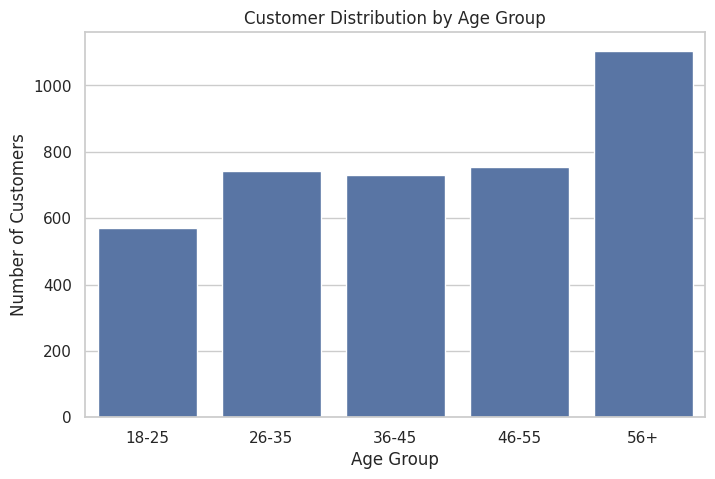

In [79]:
# Visualize customer distribution by age group

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Age Group",
    order=age_group_counts.index
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

In [80]:
# Count customers by gender

gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Male      2652
Female    1248
Name: count, dtype: int64


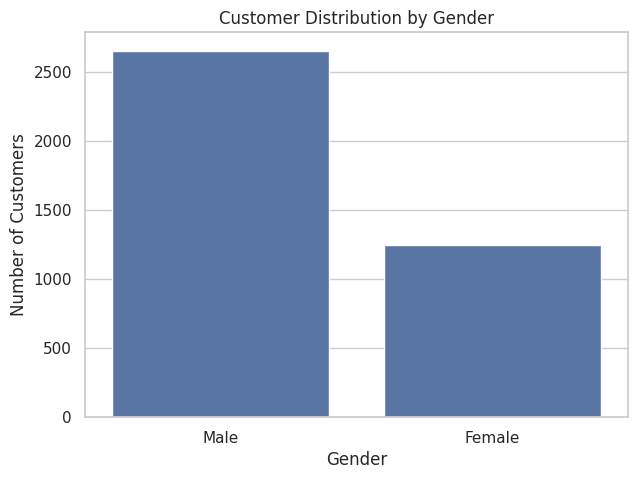

In [81]:
# Visualize gender distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## 7. Product & Category Analysis

This section examines which product categories and individual items have the strongest purchasing activity.

In [82]:
# Count purchases by category

category_counts = df["Category"].value_counts()

print(category_counts)

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


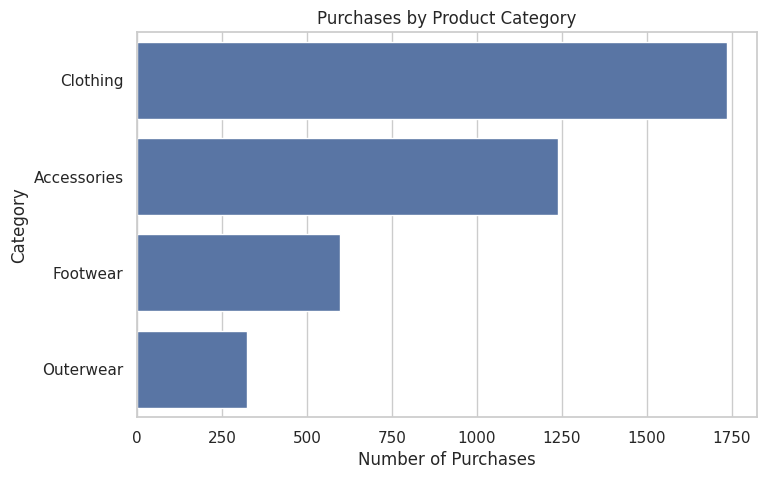

In [83]:
# Visualize purchases by category

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Purchases by Product Category")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.show()

In [84]:
# Calculate total purchase value by category

category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Purchase Amount (USD)
Category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


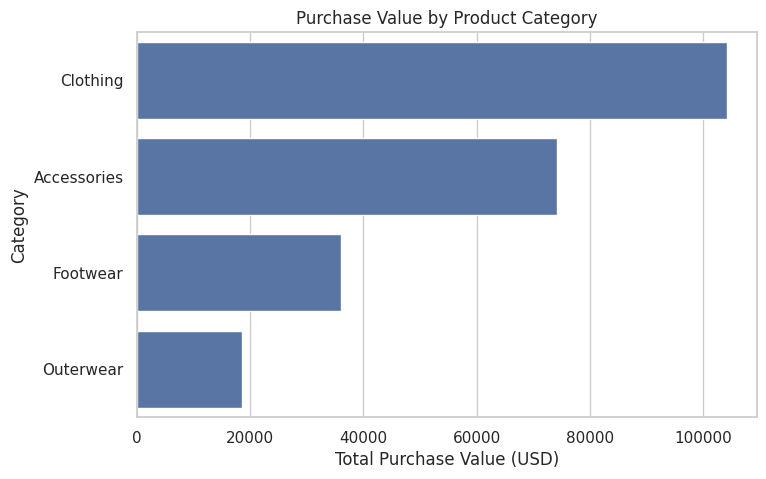

In [85]:
# Visualize purchase value by category

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Purchase Value by Product Category")
plt.xlabel("Total Purchase Value (USD)")
plt.ylabel("Category")
plt.show()

In [86]:
# Identify the most frequently purchased items

top_items = df["Item Purchased"].value_counts().head(10)

print("Top 10 Most Purchased Items:")
print(top_items)

Top 10 Most Purchased Items:
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64


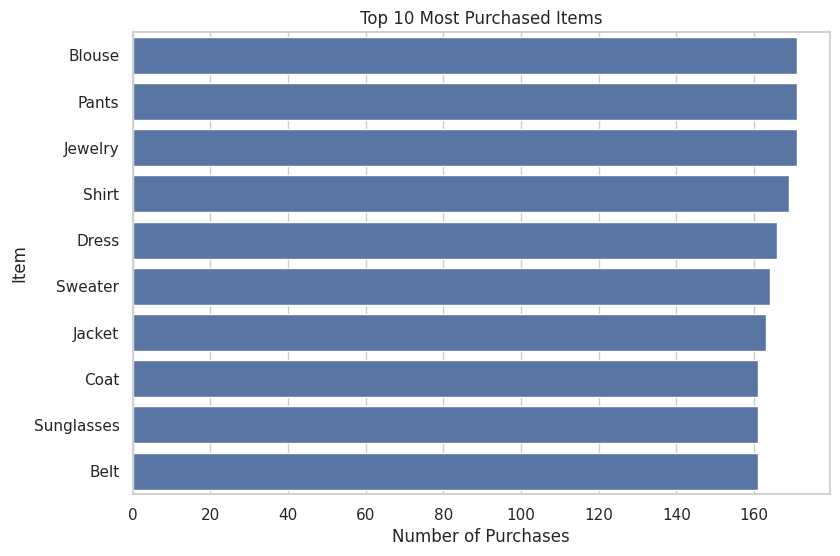

In [87]:
# Visualize the top 10 most purchased items

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top_items.values,
    y=top_items.index
)

plt.title("Top 10 Most Purchased Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Item")
plt.show()

## 8. Spending Analysis

We analyze customer spending patterns and compare purchase amounts across different customer groups.

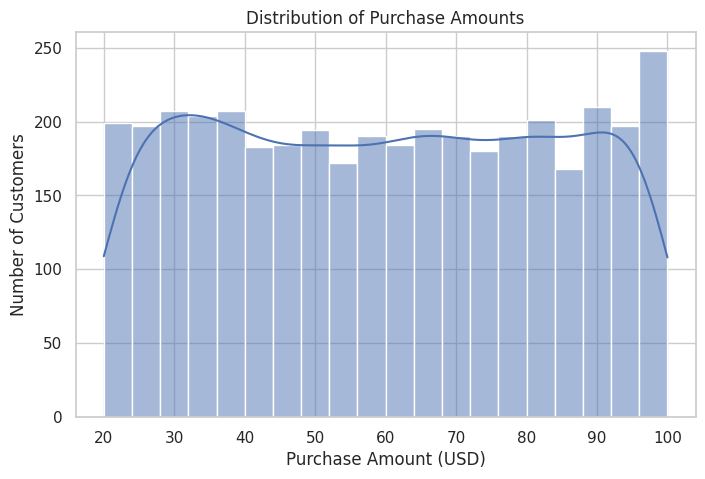

In [88]:
# Distribution of purchase amounts

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Purchase Amount (USD)",
    bins=20,
    kde=True
)

plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Customers")
plt.show()

In [89]:
# Calculate average purchase amount by gender

gender_spending = (
    df.groupby("Gender")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

print(gender_spending)

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


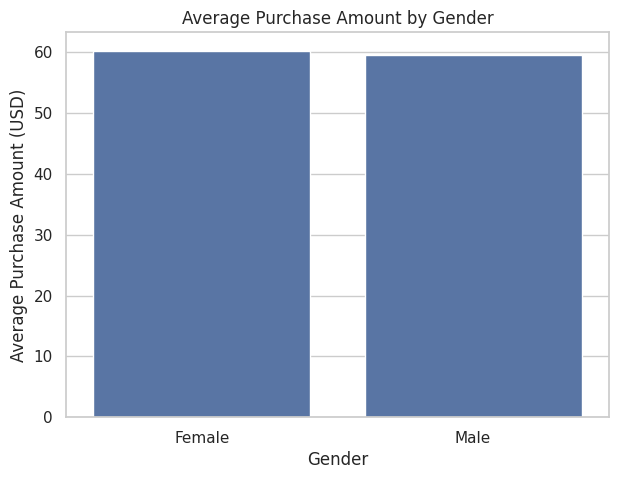

In [90]:
# Visualize average spending by gender

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_spending.index,
    y=gender_spending.values
)

plt.title("Average Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount (USD)")
plt.show()

In [91]:
# Calculate average spending by age group

age_spending = (
    df.groupby("Age Group", observed=True)["Purchase Amount (USD)"]
    .mean()
)

print(age_spending)

Age Group
18-25    60.647986
26-35    59.760108
36-45    59.305898
46-55    60.583001
56+      59.055204
Name: Purchase Amount (USD), dtype: float64


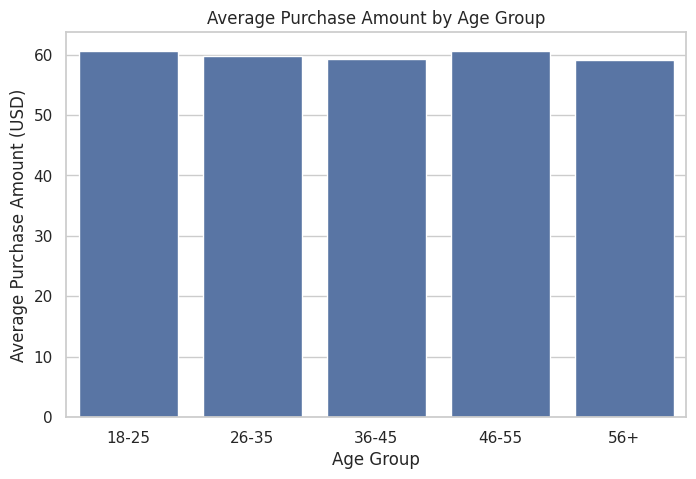

In [92]:
# Visualize average spending by age group

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_spending.index,
    y=age_spending.values
)

plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount (USD)")
plt.show()

## 9. Customer Behavior Analysis

We examine repeat purchasing, purchase frequency, and the relationship between previous purchases and current spending.

In [93]:
# Count repeat and non-repeat customers

repeat_counts = df["Repeat Customer"].value_counts()

print(repeat_counts)

Repeat Customer
Yes    3900
Name: count, dtype: int64


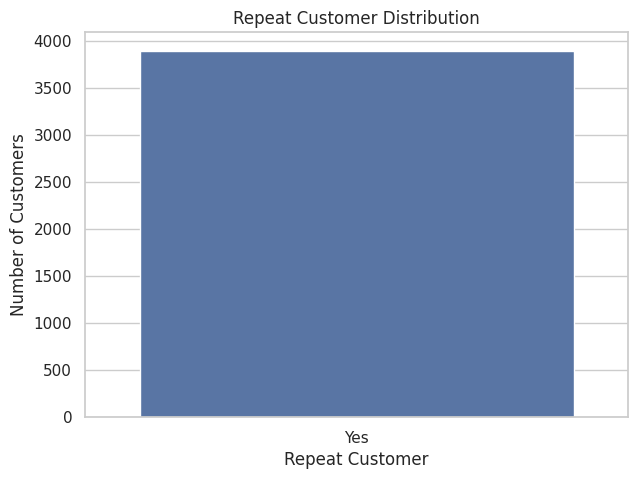

In [94]:
# Visualize repeat customer status

plt.figure(figsize=(7, 5))

sns.barplot(
    x=repeat_counts.index,
    y=repeat_counts.values
)

plt.title("Repeat Customer Distribution")
plt.xlabel("Repeat Customer")
plt.ylabel("Number of Customers")
plt.show()

In [95]:
# Analyze purchase frequency

frequency_counts = df["Frequency of Purchases"].value_counts()

print(frequency_counts)

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64


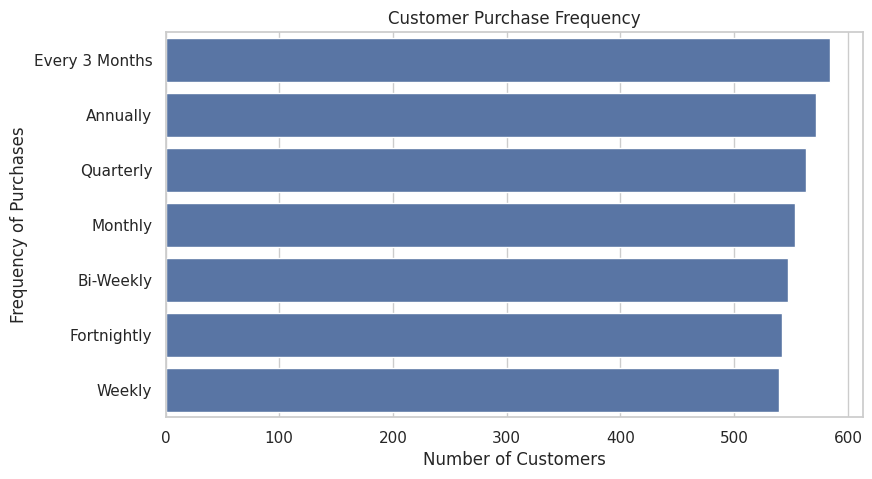

In [96]:
# Visualize purchase frequency

plt.figure(figsize=(9, 5))

sns.barplot(
    x=frequency_counts.values,
    y=frequency_counts.index
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Customers")
plt.ylabel("Frequency of Purchases")
plt.show()

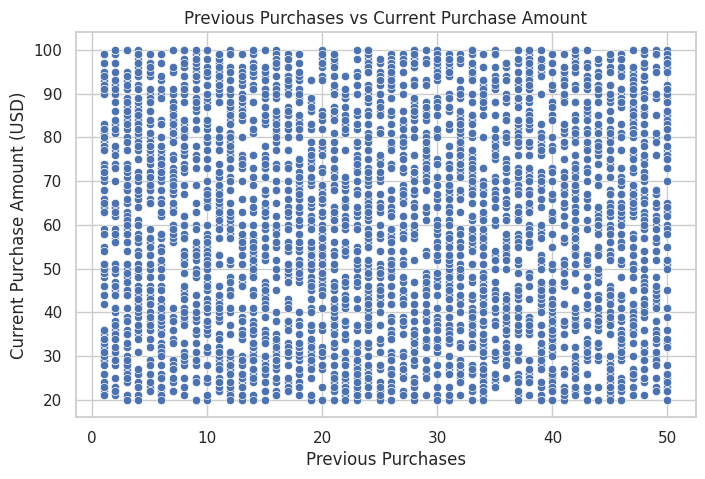

In [97]:
# Analyze relationship between previous purchases and current purchase amount

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Previous Purchases",
    y="Purchase Amount (USD)"
)

plt.title("Previous Purchases vs Current Purchase Amount")
plt.xlabel("Previous Purchases")
plt.ylabel("Current Purchase Amount (USD)")
plt.show()

## 10. Seasonal Purchasing Analysis

We compare customer purchasing activity across seasons to identify seasonal patterns.

In [98]:
# Count purchases by season

season_counts = df["Season"].value_counts()

print(season_counts)

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64


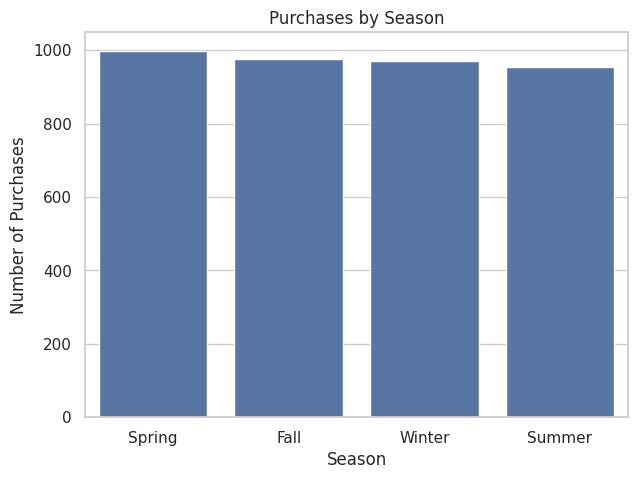

In [99]:
# Visualize purchases by season

plt.figure(figsize=(7, 5))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Purchases by Season")
plt.xlabel("Season")
plt.ylabel("Number of Purchases")
plt.show()

In [100]:
# Calculate average purchase amount by season

season_spending = (
    df.groupby("Season")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

print(season_spending)

Season
Fall      61.556923
Winter    60.357364
Spring    58.737738
Summer    58.405236
Name: Purchase Amount (USD), dtype: float64


## 11. Subscription Analysis

We compare customer spending behavior based on subscription status.

In [101]:
# Count customers by subscription status

subscription_counts = df["Subscription Status"].value_counts()

print(subscription_counts)

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


In [102]:
# Compare average spending by subscription status

subscription_spending = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

print(subscription_spending)

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64


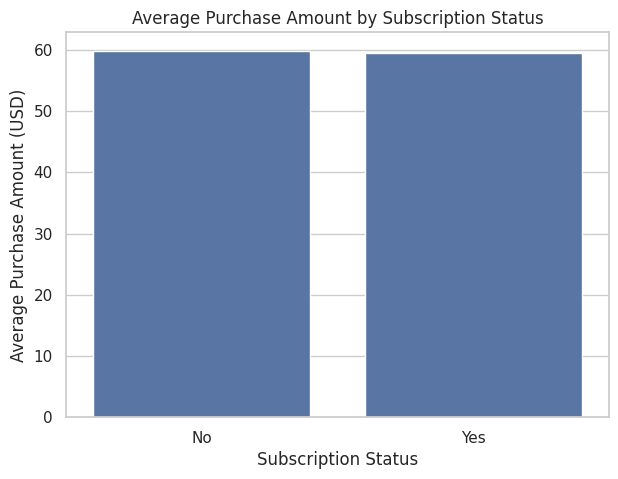

In [103]:
# Visualize average purchase amount by subscription status

plt.figure(figsize=(7, 5))

sns.barplot(
    x=subscription_spending.index,
    y=subscription_spending.values
)

plt.title("Average Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount (USD)")
plt.show()

## 12. Discount & Promotion Analysis

We compare purchasing behavior between customers who received discounts and those who did not.

In [104]:
# Count customers by discount status

discount_counts = df["Discount Applied"].value_counts()

print(discount_counts)

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64


In [105]:
# Compare average purchase amount by discount status

discount_spending = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

print(discount_spending)

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64


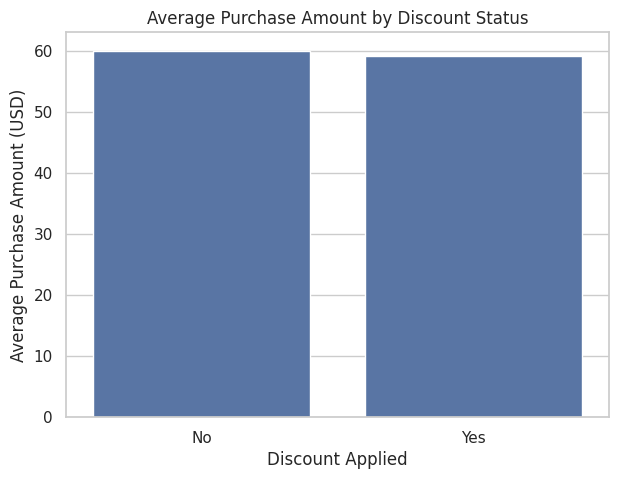

In [106]:
# Visualize spending by discount status

plt.figure(figsize=(7, 5))

sns.barplot(
    x=discount_spending.index,
    y=discount_spending.values
)

plt.title("Average Purchase Amount by Discount Status")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount (USD)")
plt.show()

## 13. Payment Method Analysis

We examine customer preferences for different payment methods.

In [107]:
# Count usage of each payment method

payment_counts = df["Payment Method"].value_counts()

print(payment_counts)

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


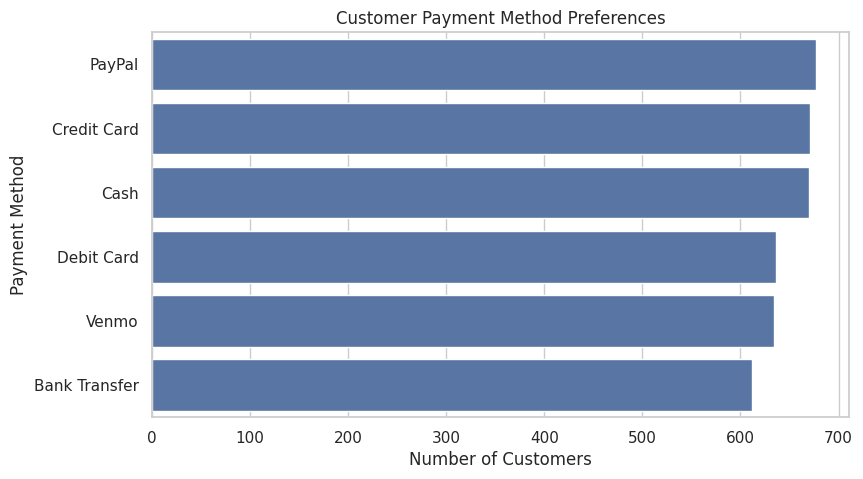

In [108]:
# Visualize payment method usage

plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_counts.values,
    y=payment_counts.index
)

plt.title("Customer Payment Method Preferences")
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")
plt.show()

## 14. Customer Segmentation

Customers are grouped into practical spending segments to compare their behavior and identify higher-value customer groups.

The segmentation is descriptive rather than predictive and is intended to support exploratory business analysis.

In [109]:
# Summarize customer segments based on spending

segment_summary = (
    df.groupby("Spending Group", observed=True)
      .agg(
          Customers=("Customer ID", "count"),
          Average_Purchase=("Purchase Amount (USD)", "mean"),
          Total_Purchase_Value=("Purchase Amount (USD)", "sum")
      )
      .sort_values("Average_Purchase", ascending=False)
)

segment_summary

,Customers,Average_Purchase,Total_Purchase_Value
Spending Group,,,
Very High,496,95.473790,47355
High,1418,75.593794,107192
Medium,1435,45.122648,64751
Low,551,25.014519,13783


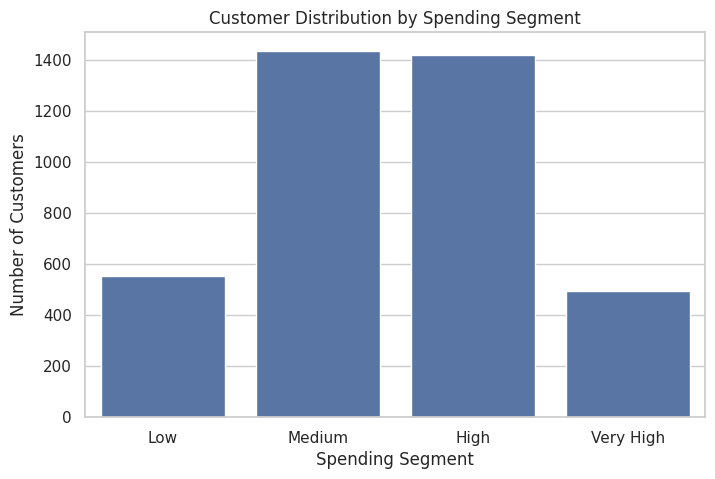

In [110]:
# Visualize the number of customers in each spending segment

segment_counts = df["Spending Group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Distribution by Spending Segment")
plt.xlabel("Spending Segment")
plt.ylabel("Number of Customers")
plt.show()

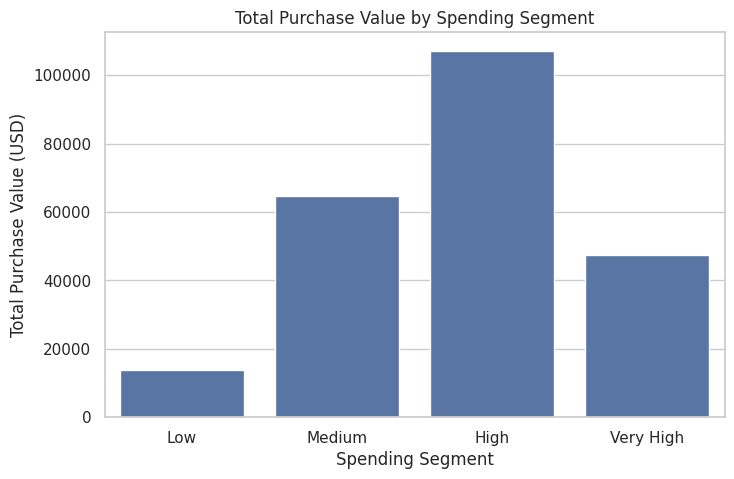

In [111]:
# Visualize total purchase value by spending segment

segment_value = (
    df.groupby("Spending Group", observed=True)["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_value.index,
    y=segment_value.values
)

plt.title("Total Purchase Value by Spending Segment")
plt.xlabel("Spending Segment")
plt.ylabel("Total Purchase Value (USD)")
plt.show()

## 15. Relationship Analysis

We examine relationships among numeric variables to identify patterns that may be useful for further investigation.

In [112]:
# Calculate correlations among important numeric variables

numeric_columns = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.010424,-0.021949,0.040445
Purchase Amount (USD),-0.010424,1.000000,0.030776,0.008063
Review Rating,-0.021949,0.030776,1.000000,0.004229
Previous Purchases,0.040445,0.008063,0.004229,1.000000


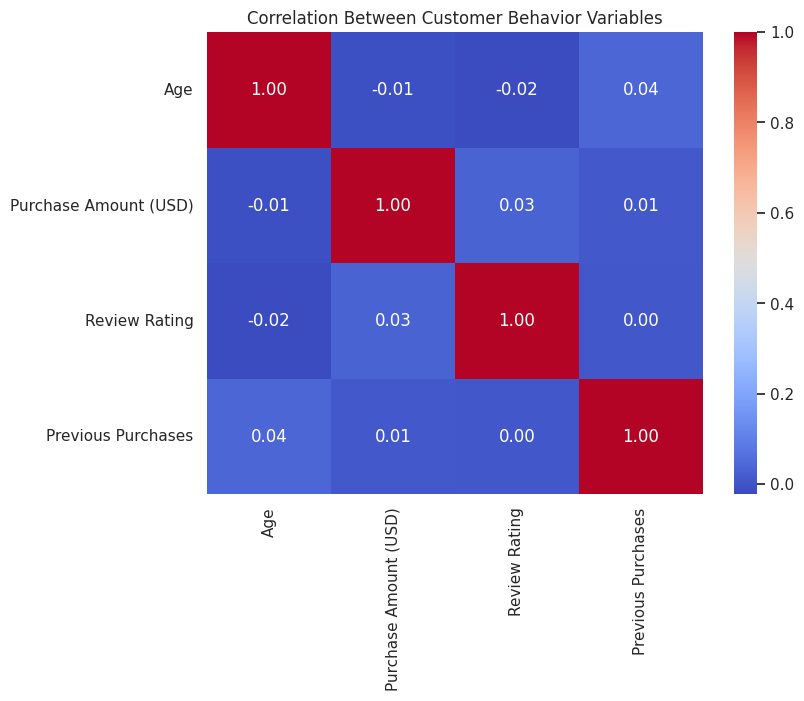

In [113]:
# Visualize the correlation matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Customer Behavior Variables")
plt.show()

## 16. Key Insights

The following insights are based on the exploratory analysis performed above.

- One product category contributes a larger share of total purchase value than the other categories.
- Certain age groups show higher average purchase amounts than others.
- Customer spending varies across subscription status.
- Some payment methods are substantially more common than others.
- The spending-segment analysis identifies a smaller group of higher-value customers.
- The relationship between previous purchases and current purchase amount should be interpreted based on the observed correlation rather than assumed causation.

## 17. Business Recommendations

Based on the observed customer behavior patterns, businesses could consider:

1. Developing targeted retention strategies for higher-value customer segments.
2. Creating personalized promotions for customer groups with different spending patterns.
3. Optimizing product and category promotions based on purchasing demand.
4. Evaluating subscription programs based on observed differences in customer spending.
5. Using preferred payment methods when designing the customer checkout experience.
6. Monitoring seasonal purchasing patterns to improve promotional planning.

## 18. Conclusion

This mini project demonstrates an end-to-end exploratory data science workflow using customer shopping data.

The analysis included:

- Dataset exploration
- Data quality checking
- Data cleaning
- Feature engineering
- Business KPI analysis
- Customer demographic analysis
- Product and category analysis
- Spending behavior analysis
- Seasonal analysis
- Subscription and discount analysis
- Payment method analysis
- Customer segmentation
- Correlation analysis
- Data visualization
- Business insights and recommendations

The project demonstrates how raw customer data can be transformed into meaningful information that can support business decision-making.

Advanced predictive modeling is intentionally left for the final project, where machine learning techniques can be applied to a more focused predictive problem.